In [ ]:
# importing labraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# styling for plots
sns.set(style="whitegrid")  
plt.rcParams['figure.figsize'] = (10, 6)

# read the dataset
data = pd.read_csv('train.csv')
print(data.shape)
print(f'Columns: {data.columns.tolist()}')
print(data.head())





(891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 310128

In [ ]:
statistics = data.describe()
print(statistics)

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


## Exploratory Data Analysis

In [ ]:
survived = data['Survived'].value_counts()
print(f'number of survivors: {survived[1]}')


number of survivors: 342


Gender survived most:
 
Survived    0    1
Sex               
female     81  233
male      468  109


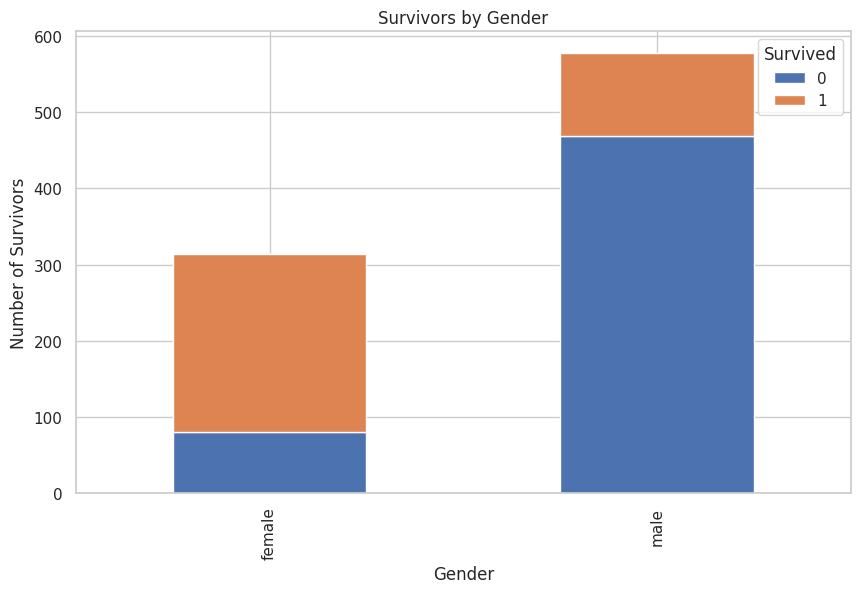

In [ ]:
# male and femeale survived more 
gender_survived_most = data.groupby(['Sex', 'Survived'])['Survived'].count().unstack()
print(f'Gender survived most:\n \n{gender_survived_most}')
gender_survived_most.plot(kind='bar', stacked=True)
plt.title('Survivors by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Survivors')
plt.show()

Class survived most:
 
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


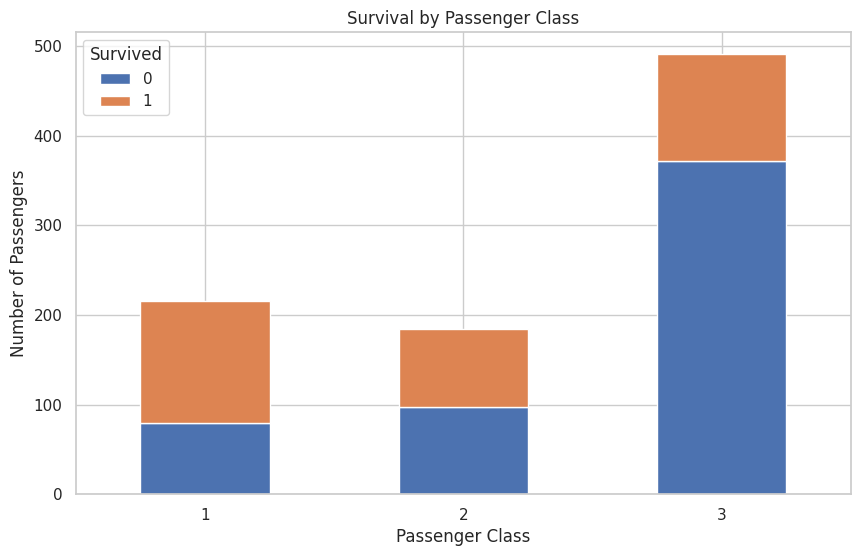

In [ ]:
# Most survived class
pclass_survived_most = data.groupby(['Pclass', 'Survived'])['Survived'].count().unstack()
print(f'Class survived most:\n \n{pclass_survived_most}')
pclass_survived_most.plot(kind='bar', stacked=True)
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)
# show plots
plt.show()

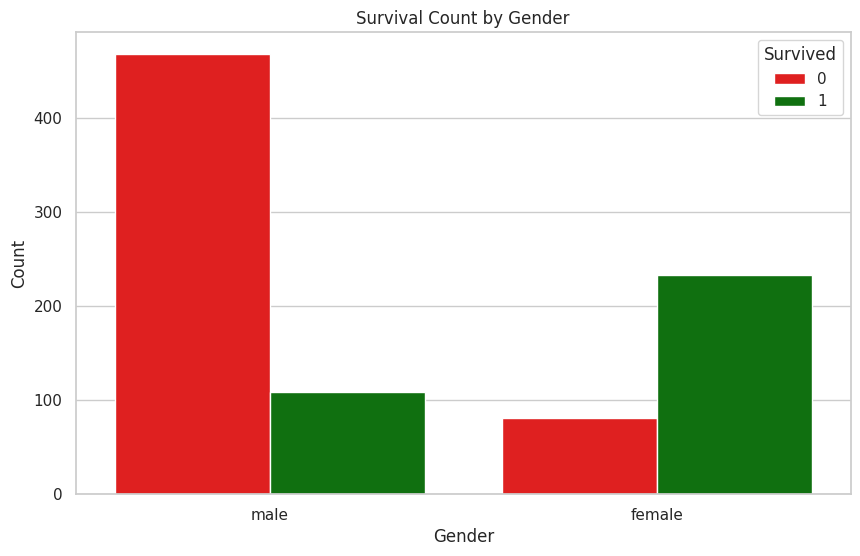

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', hue='Survived', data=data, palette=['red', 'green'])
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()# Age distribution of survivors vs non-survivors


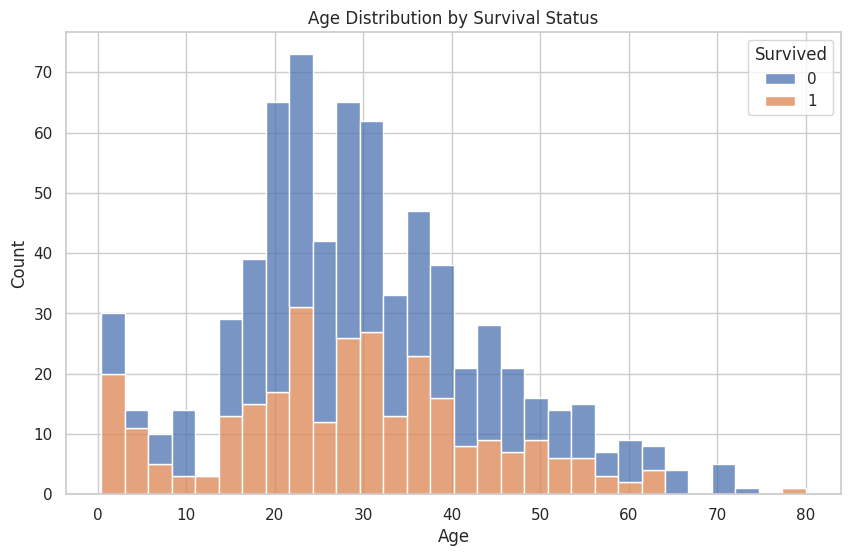

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Age', hue='Survived', multiple='stack', bins=30)
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

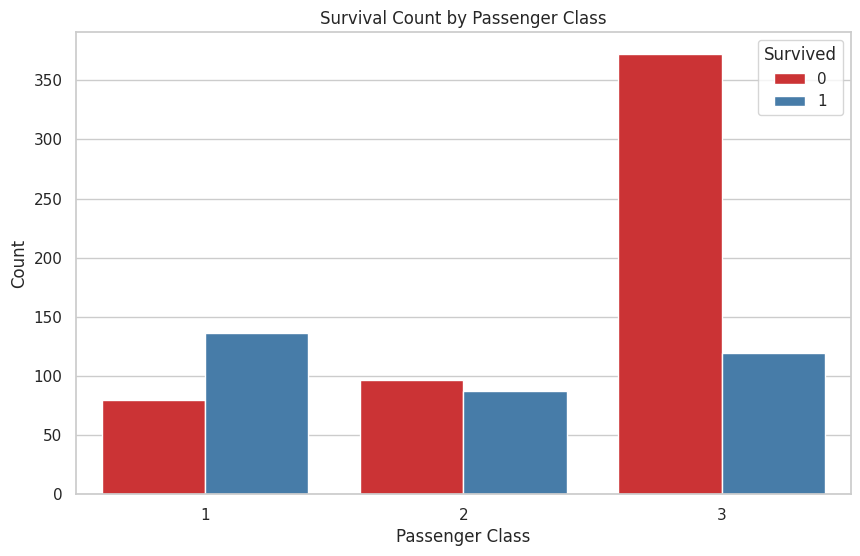

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Pclass', hue='Survived', data=data, palette='Set1')
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()# Data Preprocessing

Text(0, 0.5, 'Count')

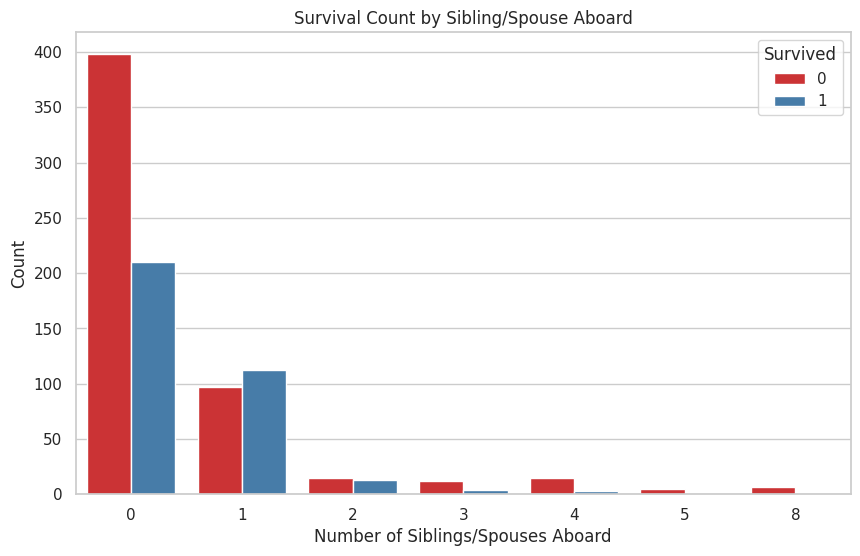

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='SibSp', hue='Survived', data=data, palette='Set1')
plt.title('Survival Count by Sibling/Spouse Aboard')
plt.xlabel('Number of Siblings/Spouses Aboard')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

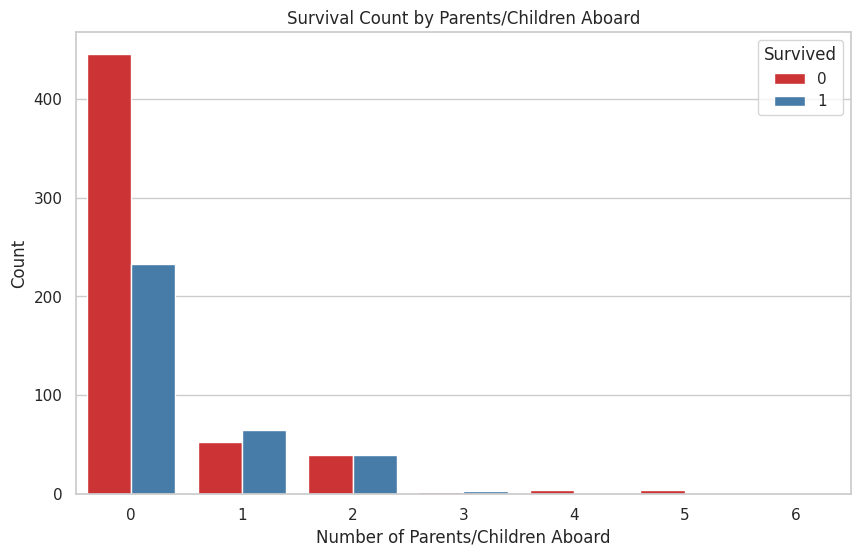

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Parch', hue='Survived', data=data, palette='Set1')
plt.title('Survival Count by Parents/Children Aboard')
plt.xlabel('Number of Parents/Children Aboard')
plt.ylabel('Count')


## Data Cleaning

          Missing Values  Percentage
Age                  177   19.865320
Cabin                687   77.104377
Embarked               2    0.224467


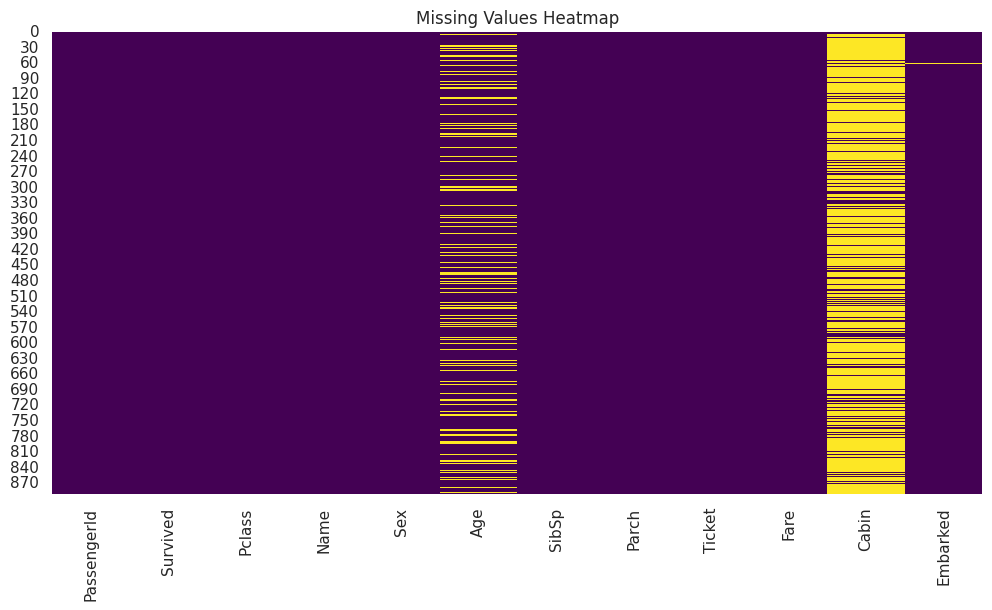

In [ ]:
# missing values
missing = data.isnull().sum()
missing_percent = (missing / len(data)) * 100
missing_data = pd.DataFrame({'Missing Values': missing, 'Percentage': missing_percent})
print(missing_data[missing_data['Missing Values'] > 0])
# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()




In [ ]:
import pandas as pd

# Group-based Age imputation
data['Age'] = (
    data.groupby(['Sex', 'Pclass'])['Age']
        .transform(lambda x: x.fillna(x.mean()))
)

# Fallback
data['Age'] = data['Age'].fillna(data['Age'].mean())


# Cabin feature
if 'Cabin' in data.columns:
    data['Has_Cabin'] = data['Cabin'].notnull().astype(int)
    data.drop(columns=['Cabin'], inplace=True)

# Embarked imputation
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# Confirm no missing values
print(data.isnull().sum()[data.isnull().sum() > 0])


Series([], dtype: int64)


In [ ]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64

## Feature Engineering

In [ ]:
# encoding sex column
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
data['Sex'].head()

0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64

In [ ]:
# encoding embaarked column(one hot encoding)
data = pd.get_dummies(
    data, 
    columns=['Embarked'], 
    drop_first=True
)

# frop unnecessary columns
data.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

print(data.dtypes)

Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Has_Cabin       int64
Embarked_Q       bool
Embarked_S       bool
dtype: object


## Modelling and Evaluation

### Split Features and Target Variable

In [ ]:
# Target variable: survived

X = data.drop('Survived', axis=1)
y = data['Survived']    

### Train/ test split the dataset into features (X) and target variable (y).

In [ ]:
from sklearn.model_selection import train_test_split    

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.columns)

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Has_Cabin',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')


### Feature Scaling(important for logistic regression)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train logistic regression model

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
print('Coeffients: ', model.coef_)
print('\nIntercept:;', model.intercept_)

Coeffients:  [[-0.69184833  1.23294425 -0.57524143 -0.28085844 -0.08588965  0.07556258
   0.40260403  0.04182542 -0.15552901]]

Intercept:; [-0.17095957]


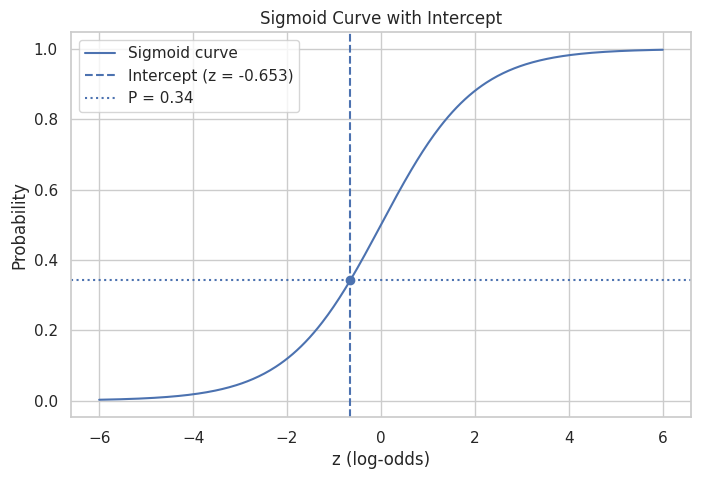

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# z values
z = np.linspace(-6, 6, 400)
p = sigmoid(z)

# intercept
intercept = -0.65307991
p_intercept = sigmoid(intercept)

# plot
plt.figure(figsize=(8, 5))
plt.plot(z, p, label='Sigmoid curve')
plt.axvline(intercept, linestyle='--', label='Intercept (z = -0.653)')
plt.axhline(p_intercept, linestyle=':', label=f'P = {p_intercept:.2f}')
plt.scatter(intercept, p_intercept)

plt.xlabel('z (log-odds)')
plt.ylabel('Probability')
plt.title('Sigmoid Curve with Intercept')
plt.legend()
plt.show()


### Make predictions on the test set

In [ ]:
y_pred = model.predict(X_test_scaled)
print((model.predict_proba(X_test_scaled)[:,1] >= 0.4).astype(int))

[0 0 0 0 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0 1 0 1 1 1 0 0 0 1 0 0 0 0 0
 1 0 1 0 1 0 1 1 0 0 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1
 0 0 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 1 0 0 1 1 1 0 0 0 0 1 1 1 0 1 0 0 0 1 0
 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 1 0 0 0 0
 1 1 0 0 1 1 1 1 0 0 0 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 0 1 0]


### Evaluate the model 

In [ ]:
from sklearn.metrics import accuracy_score 
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.77


### Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.83      0.78      0.81       110
           1       0.68      0.75      0.72        69

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.76       179
weighted avg       0.78      0.77      0.77       179



## Plot ROC Curve

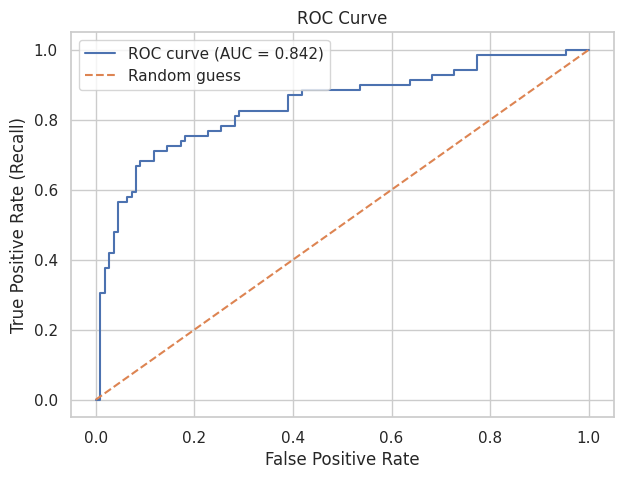

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# probabilities for class 1 (survived)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

# plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()


## Find best threshold value using Youden's J statistic

In [ ]:
import numpy as np

J = tpr - fpr
best_index = np.argmax(J)
best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)
print("TPR (Recall):", tpr[best_index])
print("FPR:", fpr[best_index])


Best threshold: 0.6274333500790542
TPR (Recall): 0.7101449275362319
FPR: 0.11818181818181818


In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[86, 24],
       [17, 52]])

### Coefficients Interpretation

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)


      Feature  Coefficient
1         Sex     1.232944
6   Has_Cabin     0.402604
5        Fare     0.075563
7  Embarked_Q     0.041825
4       Parch    -0.085890
8  Embarked_S    -0.155529
3       SibSp    -0.280858
2         Age    -0.575241
0      Pclass    -0.691848
